In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

TensorFlow Version: 2.10.0
NumPy Version: 1.23.5


In [2]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [3]:
from tensorflow.keras.utils import image_dataset_from_directory

# Dataset paths
train_dir = "../dataset/train"
valid_dir = "../dataset/valid"
test_dir = "../dataset/test"

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load datasets
train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

valid_dataset = image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Print class names
class_names = train_dataset.class_names
print("Number of classes:", len(class_names))
print(class_names)

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
Found 8179 files belonging to 38 classes.
Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_bligh

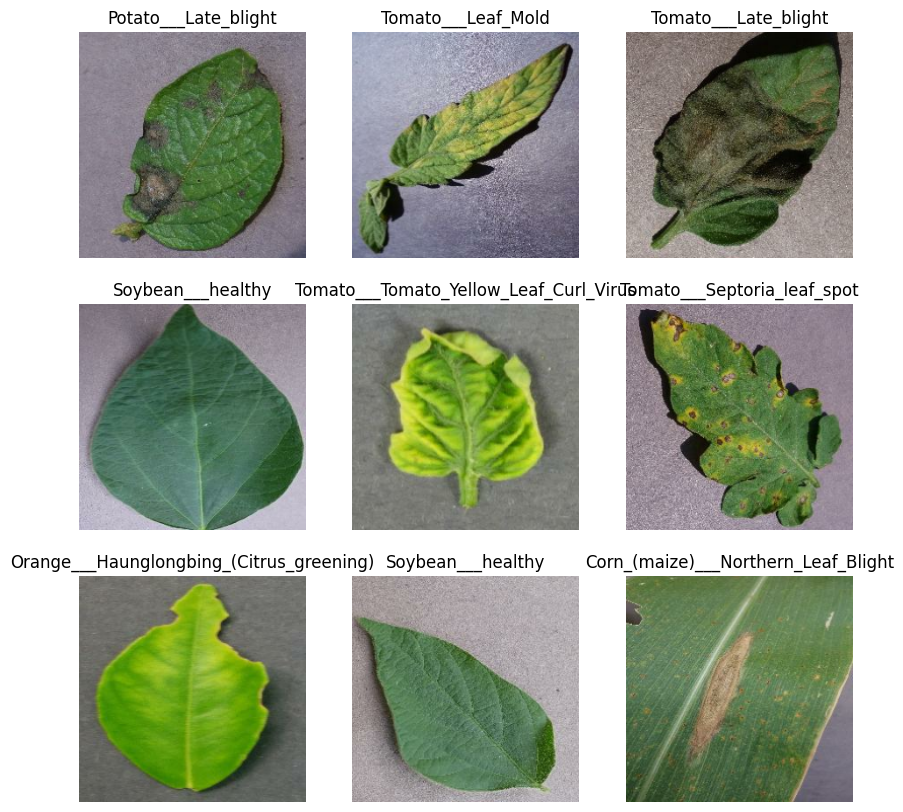

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().argmax()])
        plt.axis("off")

plt.show()

In [5]:
class_names = train_dataset.class_names

print(class_names)
print("Number of classes:", len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load pre-trained EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

# Build the model by passing a dummy input
import tensorflow as tf

dummy = tf.random.normal((1, 224, 224, 3))
_ = model(dummy)

# Show model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 38)                9766      
                                                        

In [7]:
import tensorflow as tf

dummy = tf.random.normal((1, 224, 224, 3))
_ = model(dummy)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 38)                9766      
                                                        

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the best model
checkpoint = ModelCheckpoint(
    "../models/crop_disease_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# Stop training if validation loss doesn't improve
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

256/256 [==============================] - 198s 761ms/step - loss: 3.8252 - accuracy: 0.0212
Test Loss: 3.825202465057373
Test Accuracy: 0.02115173079073429


In [12]:
import json

with open("../models/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved successfully!")

Class names saved successfully!


NameError: name 'history' is not defined

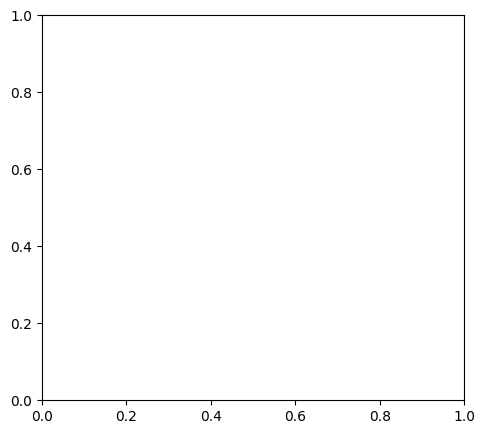

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=5,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/5
1188/1188 [==============================] - ETA: 0s - loss: 3.3819 - accuracy: 0.0982
Epoch 1: val_accuracy improved from -inf to 0.09878, saving model to ../models\crop_disease_model.keras


TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [ ]:
print(model.metrics_names)

['loss', 'accuracy']


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=5
)

Epoch 1/5
1188/1188 [==============================] - 1222s 1s/step - loss: 3.3652 - accuracy: 0.1013 - val_loss: 3.3464 - val_accuracy: 0.0988
Epoch 2/5
1188/1188 [==============================] - 1216s 1s/step - loss: 3.3623 - accuracy: 0.0992 - val_loss: 3.3463 - val_accuracy: 0.1016
Epoch 3/5
1188/1188 [==============================] - 1204s 1s/step - loss: 3.3594 - accuracy: 0.0998 - val_loss: 3.3537 - val_accuracy: 0.1016
Epoch 4/5
1188/1188 [==============================] - 1207s 1s/step - loss: 3.3570 - accuracy: 0.1005 - val_loss: 3.3450 - val_accuracy: 0.1016
Epoch 5/5
1188/1188 [==============================] - 1208s 1s/step - loss: 3.3559 - accuracy: 0.0980 - val_loss: 3.3452 - val_accuracy: 0.0988


In [ ]:
print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [ ]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("First label:", labels[0].numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32, 38)
First label: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
print(train_dataset)
print(valid_dataset)

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>
<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>


In [ ]:
print("Trainable weights:", len(model.trainable_weights))
print("Non-trainable weights:", len(model.non_trainable_weights))

for layer in model.layers:
    print(layer.name, "-", layer.trainable)

Trainable weights: 4
Non-trainable weights: 312
rescaling_8 - True
efficientnetb0 - False
global_average_pooling2d_2 - True
dropout_4 - True
dense_4 - True
dropout_5 - True
dense_5 - True


In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_8 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_4 (Dropout)         (None, 1280)              0         
                                                                 
 dense_4 (Dense)             (None, 256)               327936    
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                      

In [ ]:
import os

for split in ["train", "valid", "test"]:
    print(f"\n{split.upper()}")
    root = f"../dataset/{split}"

    for cls in sorted(os.listdir(root)):
        path = os.path.join(root, cls)
        if os.path.isdir(path):
            print(f"{cls}: {len(os.listdir(path))}")


TRAIN
Apple___Apple_scab: 441
Apple___Black_rot: 434
Apple___Cedar_apple_rust: 192
Apple___healthy: 1151
Blueberry___healthy: 1051
Cherry_(including_sour)___Powdery_mildew: 736
Cherry_(including_sour)___healthy: 597
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 359
Corn_(maize)___Common_rust_: 834
Corn_(maize)___Northern_Leaf_Blight: 689
Corn_(maize)___healthy: 813
Grape___Black_rot: 826
Grape___Esca_(Black_Measles): 968
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 753
Grape___healthy: 296
Orange___Haunglongbing_(Citrus_greening): 3854
Peach___Bacterial_spot: 1607
Peach___healthy: 251
Pepper,_bell___Bacterial_spot: 697
Pepper,_bell___healthy: 1034
Potato___Early_blight: 700
Potato___Late_blight: 700
Potato___healthy: 106
Raspberry___healthy: 259
Soybean___healthy: 3563
Squash___Powdery_mildew: 1284
Strawberry___Leaf_scorch: 776
Strawberry___healthy: 319
Tomato___Bacterial_spot: 1488
Tomato___Early_blight: 700
Tomato___Late_blight: 1336
Tomato___Leaf_Mold: 666
Tomato___Septoria_le

In [ ]:
print("Train:", train_dataset.class_names)
print("Valid:", valid_dataset.class_names)
print("Test :", test_dataset.class_names)

print(train_dataset.class_names == valid_dataset.class_names)
print(train_dataset.class_names == test_dataset.class_names)

Train: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Ta

In [ ]:
for images, labels in train_dataset.take(1):
    print(images.dtype)
    print(images.numpy().min())
    print(images.numpy().max())

<dtype: 'float32'>
0.0
255.0


In [ ]:
print("Train images:", sum(1 for _ in train_dataset.unbatch()))
print("Valid images:", sum(1 for _ in valid_dataset.unbatch()))
print("Test images :", sum(1 for _ in test_dataset.unbatch()))

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} jpeg::Uncompress failed. Invalid JPEG data or crop window.
	 [[{{node decode_image/DecodeImage}}]] [Op:IteratorGetNext]

In [ ]:
train_count = tf.data.experimental.cardinality(train_dataset).numpy()
valid_count = tf.data.experimental.cardinality(valid_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()

print("Train batches:", train_count)
print("Valid batches:", valid_count)
print("Test batches :", test_count)

Train batches: 1188
Valid batches: 255
Test batches : 256


In [ ]:
import tensorflow as tf

# Add preprocessing for EfficientNet
train_dataset = train_dataset.map(
    lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y)
)

valid_dataset = valid_dataset.map(
    lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y)
)

print("✅ EfficientNet preprocessing applied.")

✅ EfficientNet preprocessing applied.
